# AI-Driven Airline Route Profitability & Aircraft Optimization System

This project focuses on predicting airline route profitability and recommending the most suitable aircraft for a given route using machine learning and optimization techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

LOAD DATASET

In [2]:
df = pd.read_csv("../data/raw/airline_route_profitability.csv")

df.head()

,Flight_Number,Flight_Date,Origin,Destination,Route,Aircraft_Type,Aircraft_Capacity,Passengers,Load_Factor,Flight_Hours,Season,Route_Category,Demand_Level,Ticket_Revenue,Ancillary_Revenue,Total_Revenue,Fuel_Cost,Maintenance_Cost,Crew_Cost,Depreciation_Cost,Insurance_Cost,Airport_Fees,Catering_Cost,Handling_Cost,Navigation_Fees,Sales_Distribution_Cost,Passenger_Service_Cost,Overhead_Cost,Marketing_Cost,IT_Systems_Cost,Total_Cost,Profit,Profit_Margin
0,EK8960,2024-12-20,DXB,ORD,DXB-ORD,Boeing 777-300ER,396,308,0.7791,14.5,Peak,Long Haul,Medium,410785.49,53431.94,464217.43,131033.88,50750.0,21750.0,65250.0,11600.0,4262.30,5185.86,4460.11,10636.90,78193.60,5100.09,88545.73,25883.92,3769.37,506421.77,-42204.34,-9.09
1,EK3960,2024-05-13,DXB,HYD,DXB-HYD,Boeing 787-9,296,234,0.7910,4.2,Normal,Medium Haul,Medium,145890.17,17695.27,163585.44,21338.76,9240.0,5040.0,13440.0,2520.0,2016.63,5851.01,5425.84,3027.25,21586.21,6022.20,17057.61,8820.56,1937.81,123323.88,40261.57,24.61
2,EK7529,2024-10-12,DXB,CDG,DXB-CDG,Boeing 787-9,296,251,0.8502,7.5,Shoulder,Long Haul,High,602841.03,78724.16,681565.19,41011.77,16500.0,9000.0,24000.0,4500.0,10764.79,4134.08,3761.85,3431.70,100188.97,6514.22,31347.38,23695.34,3415.99,282266.09,399299.10,58.59
3,EK4543,2024-06-25,DXB,DEL,DXB-DEL,Boeing 787-9,296,229,0.7748,3.5,Low,Medium Haul,High,126485.16,17543.26,144028.42,17333.86,7700.0,4200.0,11200.0,2100.0,6508.04,6508.73,4440.93,2079.79,22686.82,4791.21,15328.62,6795.49,2245.61,113919.11,30109.31,20.91
4,EK3114,2024-04-20,DXB,RUH,DXB-RUH,Airbus A320,180,142,0.7901,2.2,Shoulder,Short Haul,Medium,32651.15,3871.66,36522.81,5576.80,2530.0,1716.0,3740.0,616.0,4718.58,3360.52,3414.18,1662.49,5133.62,3094.65,8252.23,1492.53,1273.27,46580.86,-10058.06,-27.54


DATASET SHAPE

In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 7974
Columns : 33


INFO

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7974 entries, 0 to 7973
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Flight_Number            7974 non-null   str    
 1   Flight_Date              7974 non-null   str    
 2   Origin                   7974 non-null   str    
 3   Destination              7974 non-null   str    
 4   Route                    7974 non-null   str    
 5   Aircraft_Type            7974 non-null   str    
 6   Aircraft_Capacity        7974 non-null   int64  
 7   Passengers               7974 non-null   int64  
 8   Load_Factor              7974 non-null   float64
 9   Flight_Hours             7974 non-null   float64
 10  Season                   7974 non-null   str    
 11  Route_Category           7974 non-null   str    
 12  Demand_Level             7974 non-null   str    
 13  Ticket_Revenue           7974 non-null   float64
 14  Ancillary_Revenue        7703 non-n

MISSING VALUES

In [7]:
df.isnull().sum()


Flight_Number                0
Flight_Date                  0
Origin                       0
Destination                  0
Route                        0
Aircraft_Type                0
Aircraft_Capacity            0
Passengers                   0
Load_Factor                  0
Flight_Hours                 0
Season                       0
Route_Category               0
Demand_Level                 0
Ticket_Revenue               0
Ancillary_Revenue          271
Total_Revenue                0
Fuel_Cost                    0
Maintenance_Cost             0
Crew_Cost                    0
Depreciation_Cost            0
Insurance_Cost               0
Airport_Fees                 0
Catering_Cost              265
Handling_Cost              256
Navigation_Fees              0
Sales_Distribution_Cost      0
Passenger_Service_Cost       0
Overhead_Cost                0
Marketing_Cost               0
IT_Systems_Cost              0
Total_Cost                   0
Profit                       0
Profit_M

### Missing Value Analysis

The dataset contains a small number of missing values in operational and ancillary revenue fields. Since these are numerical financial variables, median imputation was applied during preprocessing to preserve distribution stability and reduce sensitivity to outliers.

In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Ancillary_Revenue    271
Catering_Cost        265
Handling_Cost        256
dtype: int64

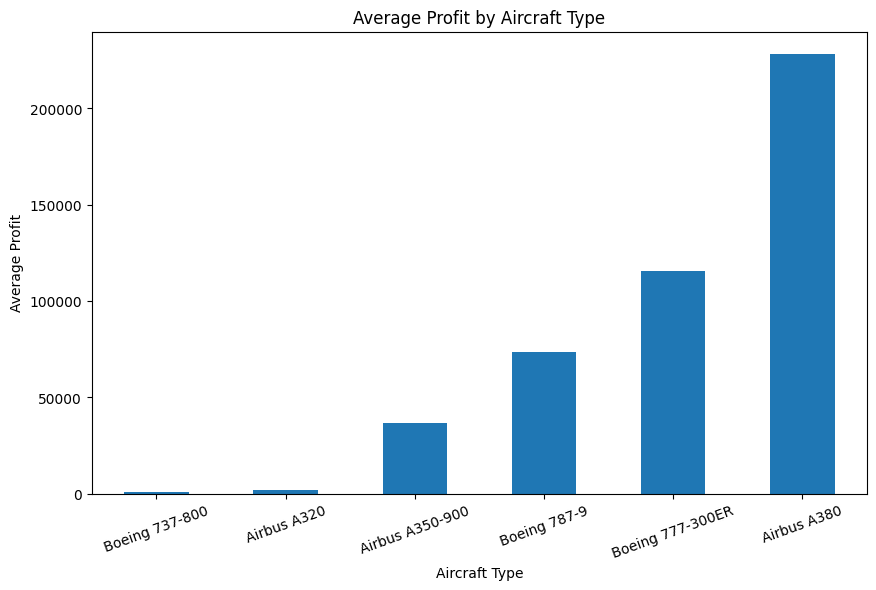

In [9]:
plt.figure(figsize=(10,6))

df.groupby("Aircraft_Type")["Profit"] \
    .mean() \
    .sort_values() \
    .plot(kind="bar")

plt.title("Average Profit by Aircraft Type")

plt.xlabel("Aircraft Type")

plt.ylabel("Average Profit")

plt.xticks(rotation=20)

plt.show()

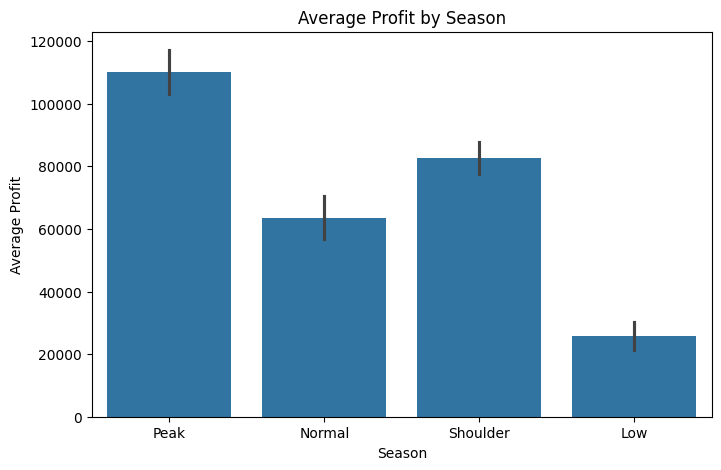

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit"
)

plt.title("Average Profit by Season")

plt.ylabel("Average Profit")

plt.show()

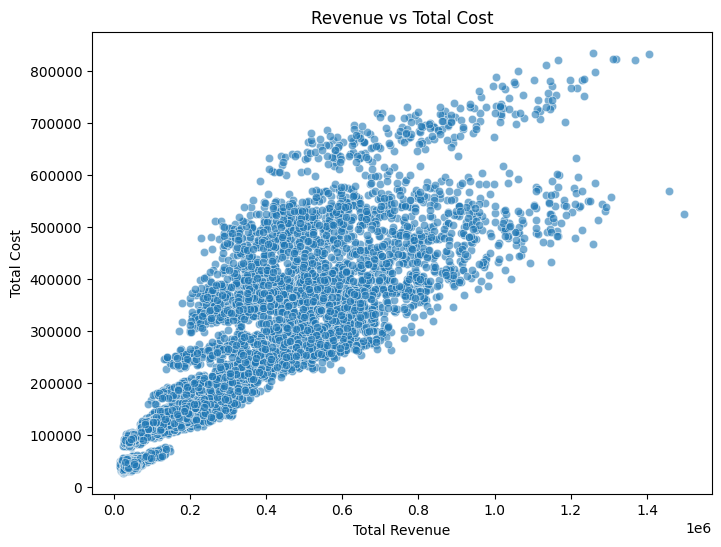

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Total_Revenue",
    y="Total_Cost",
    alpha=0.6
)

plt.title("Revenue vs Total Cost")

plt.xlabel("Total Revenue")

plt.ylabel("Total Cost")

plt.show()

### Observation

Most profitable flights operate in regions where revenue grows faster than operational cost. Flights with high operating costs but relatively lower revenue tend to produce lower profit margins or losses.

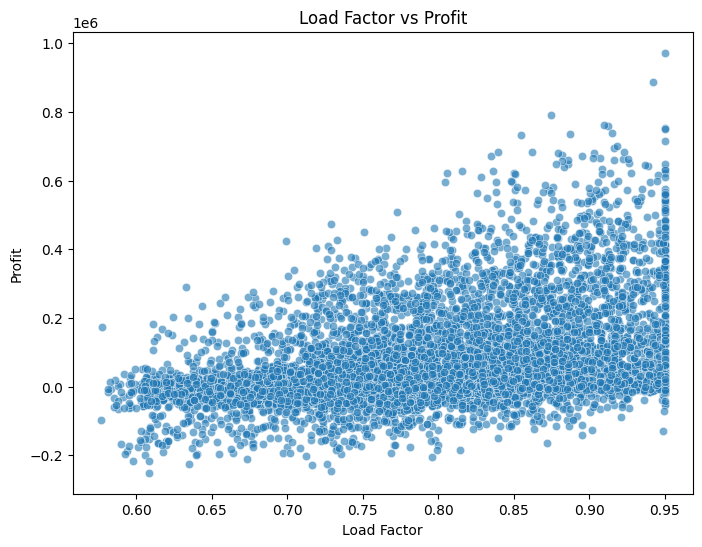

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Load_Factor",
    y="Profit",
    alpha=0.6
)

plt.title("Load Factor vs Profit")

plt.xlabel("Load Factor")

plt.ylabel("Profit")

plt.show()

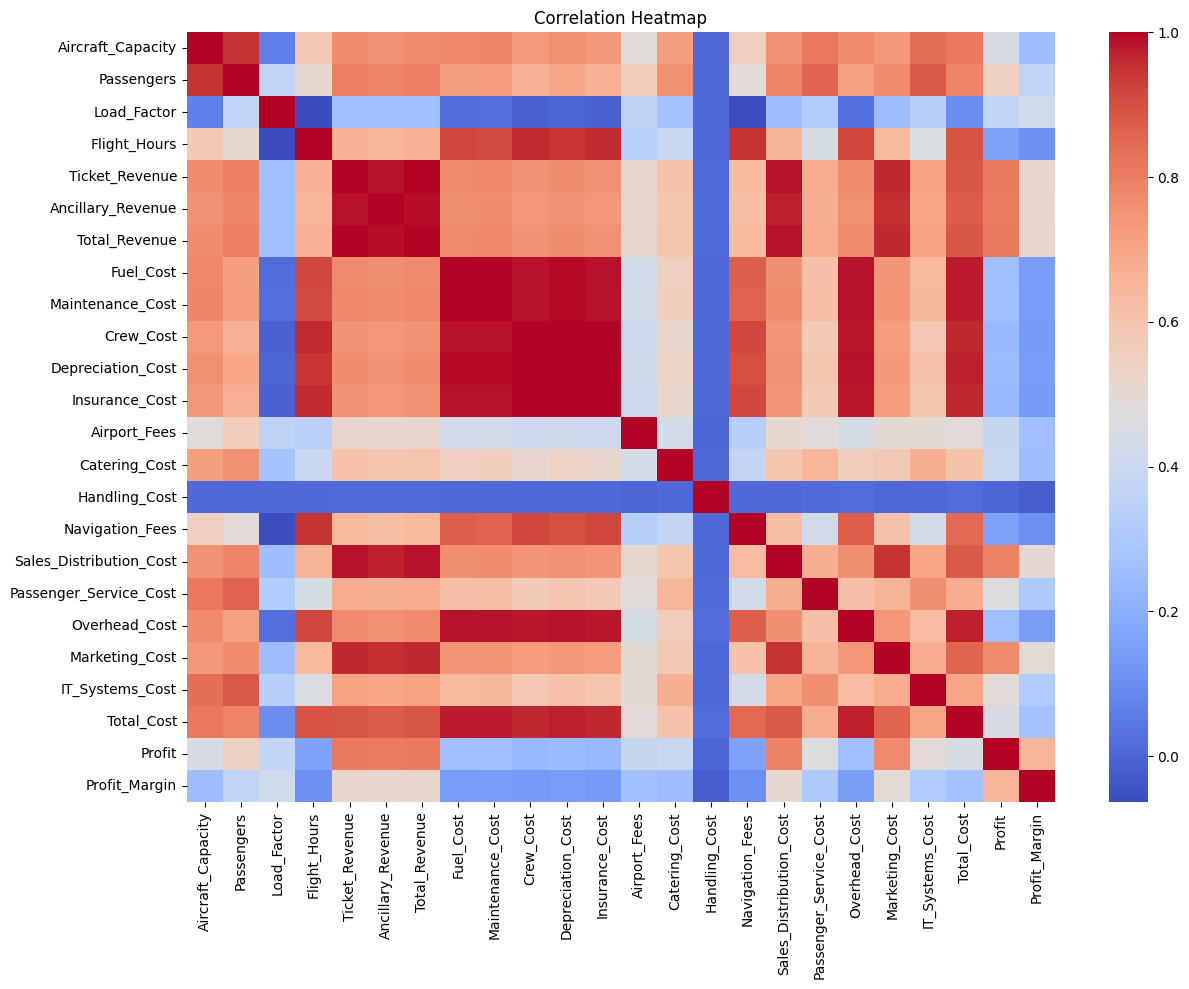

In [13]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

FEATURE ENGINEERING

To improve predictive performance, additional business-oriented features were engineered from the raw aviation dataset. These features capture operational efficiency, revenue efficiency, and cost structure relationships that influence airline profitability.

In [15]:
import sys
import os

sys.path.append("../src")

In [18]:
from preprocess import run_preprocessing

In [19]:
X, y, encoders = run_preprocessing()

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)


Dataset Loaded Successfully
Rows    : 7974
Columns : 33

Cleaning Data...
Ancillary_Revenue -> filled with median
Catering_Cost -> filled with median
Handling_Cost -> filled with median
Duplicate rows removed

Engineering Features...
Feature engineering completed

Encoding Categorical Features...
Destination encoded
Aircraft_Type encoded
Season encoded
Route_Category encoded
Demand_Level encoded

Encoders saved

Processed dataset saved

Preparing Final Dataset...
Features shape : (7974, 33)
Target shape   : (7974,)
Feature Matrix Shape : (7974, 33)
Target Shape : (7974,)


In [20]:
from train import (
    split_dataset,
    train_linear_regression,
    train_random_forest
)

SPLIT DATA

In [21]:
X_train, X_test, y_train, y_test = split_dataset(X, y)


Dataset Split Completed
Training Rows : 6379
Testing Rows  : 1595


LINEAR REGRESSION

In [22]:
lr_model, lr_results = train_linear_regression(
    X_train,
    X_test,
    y_train,
    y_test
)


Training Linear Regression...
Linear Regression Training Completed

Linear Regression Results
----------------------------------------
RMSE : 4002.70
MAE  : 2150.79
R²   : 0.9992
Linear Regression Model Saved


RANDOM FOREST

In [23]:
rf_model, rf_results = train_random_forest(
    X_train,
    X_test,
    y_train,
    y_test
)


Training Random Forest...
Random Forest Training Completed

Random Forest Results
----------------------------------------
RMSE : 11030.14
MAE  : 7107.35
R²   : 0.9936

Overfitting Check
----------------------------------------
Train R² : 0.9983
Test R²  : 0.9936
Model Generalization Looks Good
Random Forest Model Saved


In [24]:
comparison_df = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest"
    ],

    "RMSE": [
        lr_results[1],
        rf_results[1]
    ],

    "MAE": [
        lr_results[2],
        rf_results[2]
    ],

    "R2 Score": [
        lr_results[3],
        rf_results[3]
    ]
})

comparison_df

,Model,RMSE,MAE,R2 Score
0,Linear Regression,4002.698260,2150.791421,0.999163
1,Random Forest,11030.140774,7107.350411,0.993644


### Model Performance Analysis

Random Forest demonstrated strong predictive performance by effectively capturing nonlinear relationships between operational, financial, and demand-related airline variables. The model achieved high accuracy in predicting route-level profitability.

# Feature Importance Analysis

Random Forest provides feature importance scores that indicate how strongly each operational and financial variable influences airline profitability prediction.

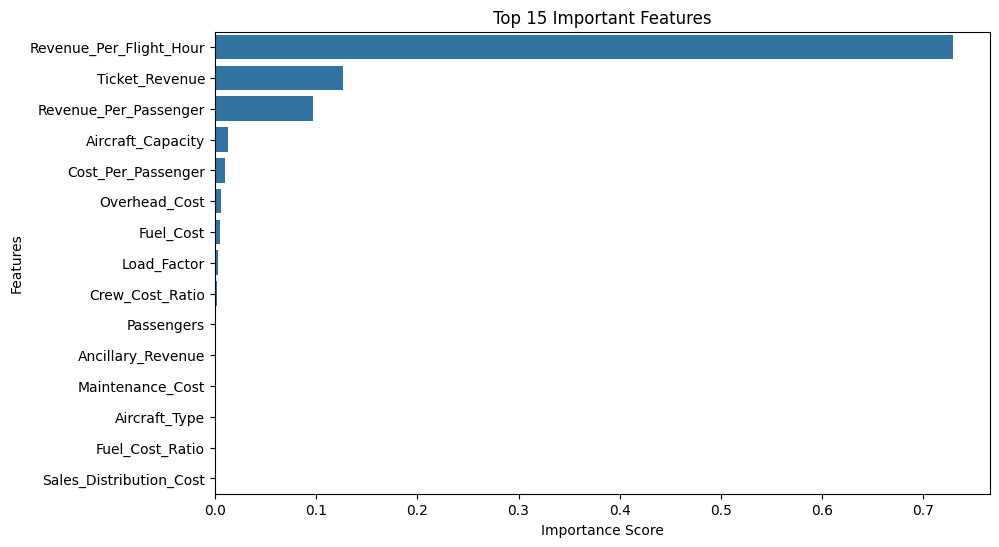

In [25]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance \
    .sort_values(ascending=False) \
    .head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Top 15 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

# Actual vs Predicted Profit Analysis

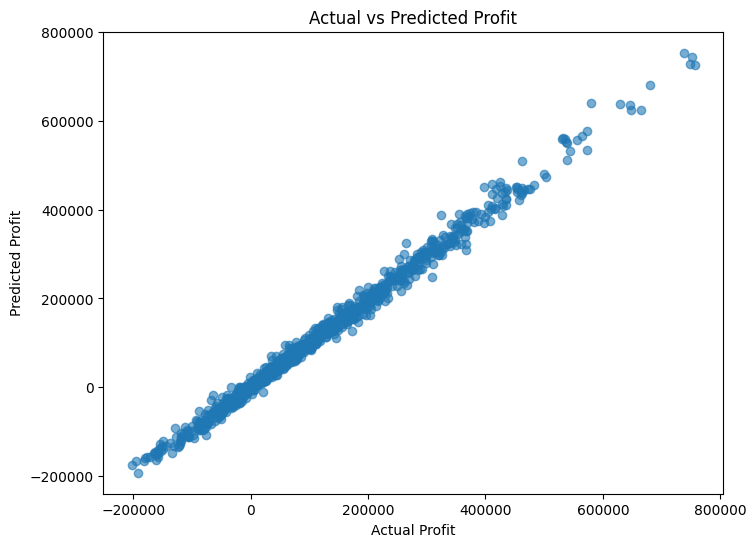

In [26]:
rf_predictions = rf_model.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

plt.xlabel("Actual Profit")

plt.ylabel("Predicted Profit")

plt.title("Actual vs Predicted Profit")

plt.show()

### Observation

The predicted profit values closely follow the actual profitability trends, indicating that the Random Forest model successfully captures operational and financial relationships within the airline dataset.

# Aircraft Optimization Engine

The optimization engine evaluates multiple aircraft options for a given route and recommends the aircraft expected to generate the highest profitability. This extends the project from predictive analytics into prescriptive analytics.

In [27]:
from optimize import recommend_aircraft

In [28]:
optimization_results = recommend_aircraft(

    destination="LHR",

    flight_hours=7.5,

    season="Peak"
)

optimization_results


Aircraft Optimization Engine

Recommended Aircraft : Airbus A380
Predicted Profit     : 57,231.43
Profit Margin        : 12.32%
Business Status      : Low Profit

Aircraft Comparison
------------------------------------------------------------
           Aircraft  Passengers  Predicted_Profit  Profit_Margin  \
5       Airbus A380         488          57231.43          12.32   
4  Boeing 777-300ER         348          40502.91          12.23   
2      Boeing 787-9         260          40423.37          16.33   
3   Airbus A350-900         324          39171.37          12.70   
0       Airbus A320         158          -6828.97          -4.54   
1    Boeing 737-800         142         -11707.09          -8.66   

  Business_Status  
5      Low Profit  
4      Low Profit  
2      Low Profit  
3      Low Profit  
0     Loss Making  
1     Loss Making  


,Aircraft,Passengers,Predicted_Profit,Profit_Margin,Business_Status
5,Airbus A380,488,57231.43,12.32,Low Profit
4,Boeing 777-300ER,348,40502.91,12.23,Low Profit
2,Boeing 787-9,260,40423.37,16.33,Low Profit
3,Airbus A350-900,324,39171.37,12.70,Low Profit
0,Airbus A320,158,-6828.97,-4.54,Loss Making
1,Boeing 737-800,142,-11707.09,-8.66,Loss Making


In [29]:
optimization_results = recommend_aircraft(

    destination="LHR",

    flight_hours=7.5,

    season="Peak"
)

optimization_results


Aircraft Optimization Engine

Recommended Aircraft : Airbus A380
Predicted Profit     : 57,231.43
Profit Margin        : 12.32%
Business Status      : Low Profit

Aircraft Comparison
------------------------------------------------------------
           Aircraft  Passengers  Predicted_Profit  Profit_Margin  \
5       Airbus A380         488          57231.43          12.32   
4  Boeing 777-300ER         348          40502.91          12.23   
2      Boeing 787-9         260          40423.37          16.33   
3   Airbus A350-900         324          39171.37          12.70   
0       Airbus A320         158          -6828.97          -4.54   
1    Boeing 737-800         142         -11707.09          -8.66   

  Business_Status  
5      Low Profit  
4      Low Profit  
2      Low Profit  
3      Low Profit  
0     Loss Making  
1     Loss Making  


,Aircraft,Passengers,Predicted_Profit,Profit_Margin,Business_Status
5,Airbus A380,488,57231.43,12.32,Low Profit
4,Boeing 777-300ER,348,40502.91,12.23,Low Profit
2,Boeing 787-9,260,40423.37,16.33,Low Profit
3,Airbus A350-900,324,39171.37,12.70,Low Profit
0,Airbus A320,158,-6828.97,-4.54,Loss Making
1,Boeing 737-800,142,-11707.09,-8.66,Loss Making


# conclusion

This project successfully developed an AI-driven airline profitability prediction and aircraft optimization system using machine learning techniques.

The system combines operational, financial, and demand-related airline data to predict route-level profitability and recommend suitable aircraft deployment strategies.

Linear Regression and Random Forest models were implemented for predictive analysis, with Random Forest achieving strong performance due to its ability to model nonlinear operational relationships.

The optimization engine extends the project from predictive analytics into prescriptive analytics by recommending the most profitable aircraft for specific routes and seasonal demand conditions.

Overall, the project demonstrates how machine learning and business analytics can support intelligent airline operational decision-making.